# FGVC-Aircraft — Manufacturer (ResNet34) — Optimized training (v2)

Objectif: pousser l'accuracy au-dessus de la baseline.

Optimisations intégrées (sans changer de backbone par défaut) :
- **Suppression bandeau copyright (20px)** + **crop bounding box** (images_box.txt) + marge
- Cache des images préprocessées (évite de recrop à chaque epoch)
- **Progressive resizing** (256 → 384 → 512) avec fine-tuning progressif
- **Mixed precision** (fp16) si dispo
- **Augmentations** + **MixUp** (option activée)
- Export du modèle dans `/kaggle/working/output/models/`

Kaggle: Internet ON.


In [1]:
from pathlib import Path
import subprocess

DATA_URL = r"""https://www.robots.ox.ac.uk/~vgg/data/fgvc-aircraft/archives/fgvc-aircraft-2013b.tar.gz"""

CACHE_DIR = Path("/kaggle/working/datasets/fgvc-aircraft-2013b")
TAR_PATH = CACHE_DIR / "fgvc-aircraft-2013b.tar.gz"
EXTRACT_DIR = CACHE_DIR / "extracted"

# Preprocessed images cache
PROC_DIR = CACHE_DIR / "processed"
PROC_IMAGES_DIR = PROC_DIR / "images_bbox_nobanner"
PROC_IMAGES_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR = Path("/kaggle/working/output")
MODEL_DIR = OUTPUT_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / "fgvc_manufacturer_resnet34_optimized_fastai.pkl"

def _run(cmd, check=True):
    p = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    print(p.stdout)
    if check and p.returncode != 0:
        raise RuntimeError(f"Command failed with exit code {p.returncode}: {' '.join(cmd)}")
    return p.returncode

def _head_bytes(path: Path, n=300):
    try:
        return path.open("rb").read(n)
    except Exception as e:
        return f"<could not read bytes: {e}>"

def validate_tarball(tar_path: Path):
    if not tar_path.exists():
        raise RuntimeError("Tarball missing after download.")
    size = tar_path.stat().st_size
    print(f"Downloaded file size: {size/1e6:.2f} MB")
    if size < 5_000_000:
        print("First bytes:", _head_bytes(tar_path))
        raise RuntimeError("Downloaded file too small; likely HTML error page or truncated download.")
    _run(["bash","-lc", f"gzip -t '{tar_path}'"])
    _run(["bash","-lc", f"tar -tzf '{tar_path}' | head"])

def download_tarball():
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    if TAR_PATH.exists() and TAR_PATH.stat().st_size > 0:
        print(f"Tarball already present: {TAR_PATH}")
        return
    print("Downloading (curl)...")
    rc = _run(["bash","-lc", f"curl -fL --retry 5 --retry-delay 2 --connect-timeout 20 --max-time 0 -o '{TAR_PATH}' '{DATA_URL}'"], check=False)
    if rc != 0:
        print("curl failed, trying wget...")
        _run(["bash","-lc", f"wget -t 5 -T 20 -O '{TAR_PATH}' '{DATA_URL}'"])

def extract_tarball():
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    if any(EXTRACT_DIR.rglob("images_box.txt")):
        print("Extraction already present.")
        return
    print("Extracting...")
    _run(["bash","-lc", f"tar -xzf '{TAR_PATH}' -C '{EXTRACT_DIR}' --no-same-owner"])

def locate_fgvc_data_dir(extract_dir: Path) -> Path:
    hits = list(extract_dir.rglob("images_box.txt"))
    if not hits:
        raise RuntimeError("Could not locate images_box.txt after extraction.")
    data_dir = hits[0].parent  # .../data
    if not (data_dir / "images").exists():
        raise RuntimeError(f"Found images_box.txt in {data_dir}, but images/ directory is missing.")
    return data_dir

def ensure_fgvc_ready():
    if EXTRACT_DIR.exists() and any(EXTRACT_DIR.rglob("images_box.txt")):
        return locate_fgvc_data_dir(EXTRACT_DIR)
    download_tarball()
    validate_tarball(TAR_PATH)
    extract_tarball()
    return locate_fgvc_data_dir(EXTRACT_DIR)

data_dir = ensure_fgvc_ready()
images_dir = data_dir / "images"

print("FGVC data_dir:", data_dir)
print("Images dir:", images_dir, "| exists:", images_dir.exists())
print("Preprocessed images dir:", PROC_IMAGES_DIR)
print("Model export path:", MODEL_PATH)


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0 2625M    0 8336k    0     0  5193k      0  0:08:37  0:00:01  0:08:36 5190k
  1 2625M    1 40.6M    0     0  15.8M      0  0:02:45  0:00:02  0:02:43 15.8M
  2 2625M    2 77.9M    0     0  21.4M      0  0:02:02  0:00:03  0:01:59 21.4M
  4 2625M    4  111M    0     0  24.2M      0  0:01:48  0:00:04  0:01:44 24.2M
  5 2625M    5  149M    0     0  26.3M      0  0:01:39  0:00:05  0:01:34 29.4M
  6 2625M    6  183M    0     0  27.7M      0  0:01:34  0:00:06  0:01:28 35.0M
  8 2625M    8  218M    0     0  28.8M      0  0:01:30  0:00:07  0:01:23 35.5M
  9 2625M    9  254M    0     0  29.5M      0  0:01:28  0:00:08  0:01:20 35.4M
 11 2625M   11  289M    0     0  30.1M      0  0:01

In [2]:
# Load manufacturer splits + bounding boxes
from pathlib import Path
import pandas as pd

def must_exist(p: Path) -> Path:
    if not p.exists():
        raise FileNotFoundError(str(p))
    return p

train_file = must_exist(data_dir / "images_manufacturer_train.txt")
val_file   = must_exist(data_dir / "images_manufacturer_val.txt")
test_file  = must_exist(data_dir / "images_manufacturer_test.txt")
bbox_file  = must_exist(data_dir / "images_box.txt")

def read_split(txt_path: Path):
    rows=[]
    with open(txt_path, "r", encoding="utf-8") as f:
        for ln, line in enumerate(f, start=1):
            line=line.strip()
            if not line:
                continue
            parts=line.split(maxsplit=1)
            if len(parts)!=2:
                raise ValueError(f"Malformed line {ln} in {txt_path}: {line!r}")
            image_id, label = parts[0], parts[1].strip()
            rows.append((image_id, label))
    return pd.DataFrame(rows, columns=["image_id","label"])

df_train = read_split(train_file)
df_val   = read_split(val_file)
df_test  = read_split(test_file)

# bbox format: image_id xmin ymin xmax ymax (1-indexed)
bbox_df = pd.read_csv(bbox_file, sep=r"\s+", header=None, names=["image_id","xmin","ymin","xmax","ymax"], engine="python")
bbox_df["image_id"] = bbox_df["image_id"].astype(str)
bbox_df.head(), len(bbox_df), df_train.head()


(  image_id  xmin  ymin  xmax  ymax
 0  1025794     3   144   998   431
 1   481847    73   220  1198   508
 2  1514522     7   217  1196   551
 3  1340192    83   155   964   462
 4   810608    19   146   986   443,
 10000,
   image_id   label
 0  1025794  Boeing
 1  1340192  Boeing
 2  0056978  Boeing
 3  0698580  Boeing
 4  0450014  Boeing)

In [3]:
# Preprocess images once: remove 20px banner, then crop bbox (+ margin), save to PROC_IMAGES_DIR
from PIL import Image
from tqdm.auto import tqdm
import numpy as np

# Build bbox dict for fast lookup
bbox_map = {row.image_id: (int(row.xmin), int(row.ymin), int(row.xmax), int(row.ymax)) for row in bbox_df.itertuples(index=False)}

ALL_IDS = pd.concat([df_train["image_id"], df_val["image_id"], df_test["image_id"]]).unique().tolist()

def crop_and_save(image_id: str, margin: float = 0.08):
    src = images_dir / f"{image_id}.jpg"
    dst = PROC_IMAGES_DIR / f"{image_id}.jpg"
    if dst.exists():
        return

    im = Image.open(src).convert("RGB")
    w, h = im.size

    # 1) remove 20px banner
    h2 = max(1, h - 20)
    im = im.crop((0, 0, w, h2))
    w, h = im.size

    # 2) bbox crop (coords are 1-indexed on original image; y is safe after banner removal by clamping)
    xmin, ymin, xmax, ymax = bbox_map.get(image_id, (1, 1, w, h))
    # convert to 0-indexed, clamp to current (banner-removed) image
    xmin = max(0, xmin - 1); ymin = max(0, ymin - 1)
    xmax = min(w, xmax);     ymax = min(h, ymax)

    # 3) add margin
    bw = max(1, xmax - xmin); bh = max(1, ymax - ymin)
    dx = int(bw * margin); dy = int(bh * margin)
    x0 = max(0, xmin - dx); y0 = max(0, ymin - dy)
    x1 = min(w, xmax + dx); y1 = min(h, ymax + dy)

    im = im.crop((x0, y0, x1, y1))
    im.save(dst, quality=95, optimize=True)

# Preprocess only missing files
missing = [iid for iid in ALL_IDS if not (PROC_IMAGES_DIR / f"{iid}.jpg").exists()]
print("Missing preprocessed images:", len(missing), "out of", len(ALL_IDS))

for iid in tqdm(missing):
    crop_and_save(iid)

# quick sanity
len(list(PROC_IMAGES_DIR.glob("*.jpg"))), (PROC_IMAGES_DIR / f"{ALL_IDS[0]}.jpg").exists()


Missing preprocessed images: 10000 out of 10000


  0%|          | 0/10000 [00:00<?, ?it/s]

(10000, True)

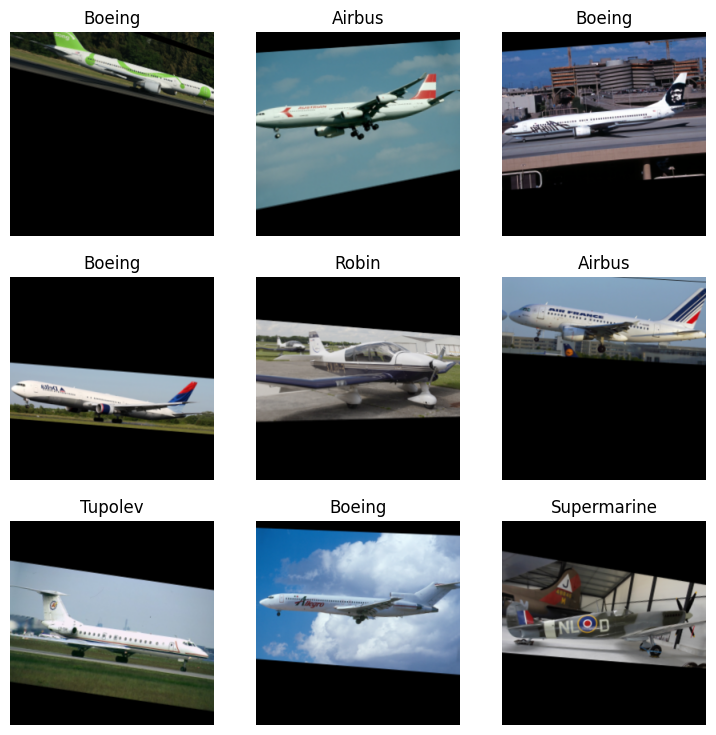

In [4]:
# Build DataLoaders (processed images) + progressive resizing utilities
from fastai.vision.all import *
from fastai.callback.mixup import MixUp

set_seed(42, reproducible=True)

df_all = pd.concat([df_train, df_val], ignore_index=True)
valid_idx = list(range(len(df_train), len(df_train)+len(df_val)))

# Backbone fixed to ResNet34 (as requested)
BACKBONE = resnet34

def make_dls(img_size: int, bs: int = 64):
    item_tfms = Resize((img_size, img_size), method=ResizeMethod.Pad, pad_mode='zeros')
    # Note: size already fixed pre-batch; keep augmentations without forcing a different size.
    batch_tfms = [*aug_transforms(min_scale=0.75), Normalize.from_stats(*imagenet_stats)]
    dls = ImageDataLoaders.from_df(
        df_all,
        path=PROC_IMAGES_DIR,
        fn_col="image_id",
        suff=".jpg",
        label_col="label",
        valid_idx=valid_idx,
        item_tfms=item_tfms,
        batch_tfms=batch_tfms,
        bs=bs,
        num_workers=2
    )
    return dls

dls_256 = make_dls(256, bs=96)
dls_256.show_batch(max_n=9)


In [5]:
# Training helpers: disable notebook progress callbacks + mixed precision + (optional) MixUp
from fastai.vision.all import *
from fastai.callback.progress import ProgressCallback, ShowGraphCallback

def build_learner(dls, use_mixup: bool = True):
    cbs = []
    if use_mixup:
        cbs.append(MixUp(alpha=0.2))
    learn = vision_learner(dls, BACKBONE, metrics=[accuracy], wd=1e-2, cbs=cbs)

    # Workaround for Kaggle progress bar crash in some environments
    try:
        learn.remove_cb(ProgressCallback)
    except Exception:
        pass
    try:
        learn.remove_cb(ShowGraphCallback)
    except Exception:
        pass

    # Mixed precision if available
    try:
        learn = learn.to_fp16()
    except Exception:
        # older fastai variants: ignore
        pass
    return learn

learn = build_learner(dls_256, use_mixup=True)
learn


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 192MB/s] 


In [6]:
# Optional: LR finder (uncomment to run)
# lr_min, lr_steep = learn.lr_find(suggest_funcs=(suggestion_minimum, suggestion_steep))
# lr_min, lr_steep


In [7]:
# Stage 1: 256px
learn.fine_tune(6, base_lr=3e-3)

# Best val accuracy at end of stage
learn.validate()


[0, 4.087567329406738, 2.366096258163452, 0.3773443400859833, '00:46']
[0, 2.834212303161621, 1.9220553636550903, 0.4726181626319885, '00:47']
[1, 2.320383071899414, 1.324451208114624, 0.5716429352760315, '00:47']
[2, 1.893595576286316, 1.131428837776184, 0.6429107189178467, '00:46']
[3, 1.5711089372634888, 0.9313865303993225, 0.6984245777130127, '00:46']
[4, 1.3401707410812378, 0.8224464058876038, 0.7366841435432434, '00:47']
[5, 1.1956204175949097, 0.8035175204277039, 0.7471867799758911, '00:46']


[0.8035175204277039, 0.7471867799758911]

In [8]:
# Stage 2: 384px (rebuild dls, keep weights)
dls_384 = make_dls(384, bs=64)
learn.dls = dls_384
learn.fine_tune(4, base_lr=2e-3)
learn.validate()


[0, 1.3454498052597046, 0.6651461720466614, 0.7696924209594727, '00:55']
[0, 1.19674551486969, 0.5490887761116028, 0.817704439163208, '00:59']
[1, 1.1421419382095337, 0.5821796655654907, 0.8079519867897034, '01:12']
[2, 0.9541792273521423, 0.39699527621269226, 0.873218297958374, '01:13']
[3, 0.8215910196304321, 0.33615222573280334, 0.8912228345870972, '01:12']


[0.33615222573280334, 0.8912228345870972]

In [9]:
# Stage 3: 512px (slower; adjust bs if OOM)
dls_512 = make_dls(512, bs=32)
learn.dls = dls_512
learn.fine_tune(3, base_lr=1e-3)
learn.validate()


[0, 0.9390063881874084, 0.2865608036518097, 0.9062265753746033, '01:29']
[0, 0.9236181378364563, 0.2813127338886261, 0.9069767594337463, '01:29']
[1, 0.8191338777542114, 0.2062637060880661, 0.9249812364578247, '01:29']
[2, 0.7442658543586731, 0.18249894678592682, 0.9377344250679016, '01:29']


[0.18249894678592682, 0.9377344250679016]

In [10]:
# Optional: TTA evaluation on validation (often +0.5-2 pts)
#preds, targs = learn.tta()
#acc = accuracy(preds, targs)
#acc


In [11]:
# Export model
learn.export(MODEL_PATH)
MODEL_PATH


Path('/kaggle/working/output/models/fgvc_manufacturer_resnet34_optimized_fastai.pkl')

In [12]:
# Quick sanity inference on a few test images
learn_inf = load_learner(MODEL_PATH)

for image_id in df_test.sample(8, random_state=42)["image_id"].tolist():
    p = PROC_IMAGES_DIR / f"{image_id}.jpg"
    pred, pred_idx, probs = learn_inf.predict(p)
    print(p.name, "->", pred)


/usr/local/lib/python3.12/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


0946093.jpg -> Boeing
1903311.jpg -> Gulfstream Aerospace
0126154.jpg -> Beechcraft
1191372.jpg -> de Havilland
1966298.jpg -> Embraer
1191125.jpg -> Saab
0554934.jpg -> Douglas Aircraft Company
1795553.jpg -> Boeing
